# IPL Data Analysis (2008–2020)

# Objective

The objective of this project is to analyze Indian Premier League (IPL) data from 2008 to 2020 to identify meaningful patterns and insights related to team performance, match outcomes, venues, toss decisions, and player achievements.

The project also involves data cleaning, data validation, exploratory data analysis, and visualization using Python. Both match-level and ball-by-ball datasets will be analyzed to understand IPL performance from different perspectives.

# Dataset

This project uses two IPL datasets:

# 1. Match-Level Dataset
Contains information about individual IPL matches, including:
- Match ID
- City
- Date
- Venue
- Teams
- Toss winner and decision
- Match winner
- Result and result margin
- Player of the Match
- Umpires

# 2. Ball-by-Ball Dataset
Contains detailed information about each delivery, including:
- Match ID
- Batting and bowling teams
- Over and ball information
- Batter and bowler
- Runs scored
- Extra runs
- Wickets and dismissal information
The datasets cover IPL matches played between 2008 and 2020.

# Tools Used

1. Python — Data analysis and processing
2. Pandas — Data cleaning and manipulation
3. NumPy — Numerical operations
4. Matplotlib — Data visualization
5. SQLite — Data storage and SQL analysis
6. SQL — Querying and analyzing the data
7. Jupyter Notebook — Project development and documentation

# Questions to Answer

# Match-Level Analysis
1. How many matches were played in each IPL season?
2. Which teams have won the most matches?
3. Which teams have the highest winning percentage?
4. Which venues have hosted the most IPL matches?
5. Which players have won the most Player of the Match awards?
6. Does winning the toss increase the chances of winning the match?
7. What are the most common toss decisions?
8. Which teams perform best after choosing to bat or field?
# Ball-by-Ball Analysis
9. Who are the top run scorers in IPL from 2008–2020?
10. Which players have hit the most sixes?
11. Which bowlers have taken the most wickets?
12. Which teams have scored the most runs?
13. What are the highest-scoring matches?
14. Which teams have the highest average runs per match?

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot  as plt

In [3]:
match = pd.read_csv('IPL Matches 2008-2020.csv')
ball_by_ball = pd.read_csv('IPL Ball-by-Ball 2008-2020.csv')

In [4]:
match.head()

,id,city,date,player_of_match,venue,neutral_venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,eliminator,method,umpire1,umpire2
0,335982.0,Bangalore,4/18/08,BB McCullum,M Chinnaswamy Stadium,0.0,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,N,NaN,Asad Rauf,RE Koertzen
1,335983.0,Chandigarh,4/19/08,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",0.0,Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,N,NaN,MR Benson,SL Shastri
2,335984.0,Delhi,4/19/08,MF Maharoof,Feroz Shah Kotla,0.0,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985.0,Mumbai,4/20/08,MV Boucher,Wankhede Stadium,0.0,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,N,NaN,SJ Davis,DJ Harper
4,335986.0,Kolkata,4/20/08,DJ Hussey,Eden Gardens,0.0,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,N,NaN,BF Bowden,K Hariharan


In [5]:
match.shape

(999, 17)

In [6]:
ball_by_ball.head()

,id,inning,over,ball,batsman,non_striker,bowler,batsman_runs,extra_runs,total_runs,non_boundary,is_wicket,dismissal_kind,player_dismissed,fielder,extras_type,batting_team,bowling_team
0,335982,1,6,5,RT Ponting,BB McCullum,AA Noffke,1,0,1,0,0,NaN,NaN,NaN,NaN,Kolkata Knight Riders,Royal Challengers Bangalore
1,335982,1,6,6,BB McCullum,RT Ponting,AA Noffke,1,0,1,0,0,NaN,NaN,NaN,NaN,Kolkata Knight Riders,Royal Challengers Bangalore
2,335982,1,7,1,BB McCullum,RT Ponting,Z Khan,0,0,0,0,0,NaN,NaN,NaN,NaN,Kolkata Knight Riders,Royal Challengers Bangalore
3,335982,1,7,2,BB McCullum,RT Ponting,Z Khan,1,0,1,0,0,NaN,NaN,NaN,NaN,Kolkata Knight Riders,Royal Challengers Bangalore
4,335982,1,7,3,RT Ponting,BB McCullum,Z Khan,1,0,1,0,0,NaN,NaN,NaN,NaN,Kolkata Knight Riders,Royal Challengers Bangalore


In [7]:
ball_by_ball.shape

(193468, 18)

# Match data 

In [8]:
match.shape

(999, 17)

In [9]:
match.isnull().sum()

id                 183
city               196
date               183
player_of_match    187
venue              183
neutral_venue      183
team1              183
team2              183
toss_winner        183
toss_decision      183
winner             187
result             187
result_margin      200
eliminator         187
method             980
umpire1            183
umpire2            183
dtype: int64

In [10]:
match.duplicated().sum()

np.int64(182)

In [11]:
match[match.duplicated(keep=False)]

,id,city,date,player_of_match,venue,neutral_venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,eliminator,method,umpire1,umpire2
816,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
817,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
818,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
819,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
820,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
994,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
995,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
996,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
997,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
match.isna().all(axis=1).sum()

np.int64(183)

In [13]:
match[match.isna().all(axis=1)].shape

(183, 17)

In [14]:
match = match.dropna(how="all")

In [15]:
match.shape

(816, 17)

In [16]:
match.duplicated().sum()

np.int64(0)

In [17]:
match.info()

<class 'pandas.core.frame.DataFrame'>
Index: 816 entries, 0 to 815
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               816 non-null    float64
 1   city             803 non-null    object 
 2   date             816 non-null    object 
 3   player_of_match  812 non-null    object 
 4   venue            816 non-null    object 
 5   neutral_venue    816 non-null    float64
 6   team1            816 non-null    object 
 7   team2            816 non-null    object 
 8   toss_winner      816 non-null    object 
 9   toss_decision    816 non-null    object 
 10  winner           812 non-null    object 
 11  result           812 non-null    object 
 12  result_margin    799 non-null    float64
 13  eliminator       812 non-null    object 
 14  method           19 non-null     object 
 15  umpire1          816 non-null    object 
 16  umpire2          816 non-null    object 
dtypes: float64(3), object

# Cleaning

In [18]:
match['id'] = match['id'].astype('Int64')

In [19]:
match['date']

0       4/18/08
1       4/19/08
2       4/19/08
3       4/20/08
4       4/20/08
         ...   
811     9/28/20
812     11/5/20
813     11/6/20
814     11/8/20
815    11/10/20
Name: date, Length: 816, dtype: object

In [20]:
match['date'] = pd.to_datetime(
    match['date'],
    format='%m/%d/%y'
)

In [21]:
match['date'].head(10)

0   2008-04-18
1   2008-04-19
2   2008-04-19
3   2008-04-20
4   2008-04-20
5   2008-04-21
6   2008-04-22
7   2008-04-23
8   2008-04-24
9   2008-04-25
Name: date, dtype: datetime64[ns]

In [22]:
match['neutral_venue'].unique()

array([0., 1.])

In [23]:
match['result_margin'] = match['result_margin'].astype('Int64')

In [24]:
match['eliminator'].unique()

array(['N', 'Y', nan], dtype=object)

In [25]:
match['method'].unique()

array([nan, 'D/L'], dtype=object)

In [26]:
match.head(2)

,id,city,date,player_of_match,venue,neutral_venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,eliminator,method,umpire1,umpire2
0,335982,Bangalore,2008-04-18,BB McCullum,M Chinnaswamy Stadium,0.0,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140,N,NaN,Asad Rauf,RE Koertzen
1,335983,Chandigarh,2008-04-19,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",0.0,Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33,N,NaN,MR Benson,SL Shastri


In [27]:
match.info()

<class 'pandas.core.frame.DataFrame'>
Index: 816 entries, 0 to 815
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   id               816 non-null    Int64         
 1   city             803 non-null    object        
 2   date             816 non-null    datetime64[ns]
 3   player_of_match  812 non-null    object        
 4   venue            816 non-null    object        
 5   neutral_venue    816 non-null    float64       
 6   team1            816 non-null    object        
 7   team2            816 non-null    object        
 8   toss_winner      816 non-null    object        
 9   toss_decision    816 non-null    object        
 10  winner           812 non-null    object        
 11  result           812 non-null    object        
 12  result_margin    799 non-null    Int64         
 13  eliminator       812 non-null    object        
 14  method           19 non-null     object        

# Null values in a col

In [28]:
match.isnull().sum()

id                   0
city                13
date                 0
player_of_match      4
venue                0
neutral_venue        0
team1                0
team2                0
toss_winner          0
toss_decision        0
winner               4
result               4
result_margin       17
eliminator           4
method             797
umpire1              0
umpire2              0
dtype: int64

In [29]:
print(round((match.isnull().sum() / len(match) * 100).sort_values(ascending=False),2))

method             97.67
result_margin       2.08
city                1.59
winner              0.49
player_of_match     0.49
eliminator          0.49
result              0.49
id                  0.00
umpire1             0.00
toss_winner         0.00
toss_decision       0.00
team2               0.00
team1               0.00
neutral_venue       0.00
venue               0.00
date                0.00
umpire2             0.00
dtype: float64


# 3. Check unique values

In [30]:
for col in match.select_dtypes(include="object").columns:
    print("\n", col)
    print(match[col].unique())


 city
['Bangalore' 'Chandigarh' 'Delhi' 'Mumbai' 'Kolkata' 'Jaipur' 'Hyderabad'
 'Chennai' 'Cape Town' 'Port Elizabeth' 'Durban' 'Centurion' 'East London'
 'Johannesburg' 'Kimberley' 'Bloemfontein' 'Ahmedabad' 'Cuttack' 'Nagpur'
 'Dharamsala' 'Kochi' 'Indore' 'Visakhapatnam' 'Pune' 'Raipur' 'Ranchi'
 'Abu Dhabi' nan 'Rajkot' 'Kanpur' 'Bengaluru' 'Dubai' 'Sharjah']

 player_of_match
['BB McCullum' 'MEK Hussey' 'MF Maharoof' 'MV Boucher' 'DJ Hussey'
 'SR Watson' 'V Sehwag' 'ML Hayden' 'YK Pathan' 'KC Sangakkara' 'JDP Oram'
 'AC Gilchrist' 'SM Katich' 'MS Dhoni' 'ST Jayasuriya' 'GD McGrath'
 'SE Marsh' 'SA Asnodkar' 'R Vinay Kumar' 'IK Pathan' 'SM Pollock'
 'Sohail Tanvir' 'S Sreesanth' 'A Nehra' 'SC Ganguly' 'CRD Fernando'
 'L Balaji' 'Shoaib Akhtar' 'A Mishra' 'DPMD Jayawardene' 'GC Smith'
 'DJ Bravo' 'M Ntini' 'SP Goswami' 'A Kumble' 'KD Karthik' 'JA Morkel'
 'P Kumar' 'Umar Gul' 'SK Raina' 'SR Tendulkar' 'R Dravid' 'DL Vettori'
 'RP Singh' 'M Muralitharan' 'CH Gayle' 'AB de Villiers'

In [31]:
match['team1'].value_counts()

team1
Royal Challengers Bangalore    108
Mumbai Indians                  97
Kolkata Knight Riders           95
Chennai Super Kings             94
Kings XI Punjab                 92
Delhi Daredevils                83
Rajasthan Royals                70
Sunrisers Hyderabad             59
Deccan Chargers                 39
Pune Warriors                   23
Delhi Capitals                  19
Gujarat Lions                   16
Kochi Tuskers Kerala             7
Rising Pune Supergiants          7
Rising Pune Supergiant           7
Name: count, dtype: int64

In [32]:
match['team1'].value_counts()

team1
Royal Challengers Bangalore    108
Mumbai Indians                  97
Kolkata Knight Riders           95
Chennai Super Kings             94
Kings XI Punjab                 92
Delhi Daredevils                83
Rajasthan Royals                70
Sunrisers Hyderabad             59
Deccan Chargers                 39
Pune Warriors                   23
Delhi Capitals                  19
Gujarat Lions                   16
Kochi Tuskers Kerala             7
Rising Pune Supergiants          7
Rising Pune Supergiant           7
Name: count, dtype: int64

In [33]:
match['team2'].value_counts()

team2
Mumbai Indians                 106
Kings XI Punjab                 98
Kolkata Knight Riders           97
Rajasthan Royals                91
Royal Challengers Bangalore     87
Chennai Super Kings             84
Delhi Daredevils                78
Sunrisers Hyderabad             65
Deccan Chargers                 36
Pune Warriors                   23
Gujarat Lions                   14
Delhi Capitals                  14
Rising Pune Supergiant           9
Kochi Tuskers Kerala             7
Rising Pune Supergiants          7
Name: count, dtype: int64

In [34]:
match["result_margin"].describe()

count        799.0
mean     17.321652
std      22.068427
min            1.0
25%            6.0
50%            8.0
75%           19.5
max          146.0
Name: result_margin, dtype: Float64

In [35]:
match.head(2)

,id,city,date,player_of_match,venue,neutral_venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,eliminator,method,umpire1,umpire2
0,335982,Bangalore,2008-04-18,BB McCullum,M Chinnaswamy Stadium,0.0,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140,N,NaN,Asad Rauf,RE Koertzen
1,335983,Chandigarh,2008-04-19,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",0.0,Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33,N,NaN,MR Benson,SL Shastri


# 4. Check numerical columns

In [36]:
match.describe()

,id,date,neutral_venue,result_margin
count,816.0,816,816.000000,799.0
mean,756349.553922,2014-04-13 19:07:03.529411840,0.094363,17.321652
min,335982.0,2008-04-18 00:00:00,0.000000,1.0
25%,501227.75,2011-04-26 18:00:00,0.000000,6.0
50%,729298.0,2014-04-23 12:00:00,0.000000,8.0
75%,1082626.25,2017-04-30 00:00:00,0.000000,19.5
max,1237181.0,2020-11-10 00:00:00,1.000000,146.0
std,305894.254804,NaN,0.292512,22.068427


In [37]:
match["result_margin"].describe()

count        799.0
mean     17.321652
std      22.068427
min            1.0
25%            6.0
50%            8.0
75%           19.5
max          146.0
Name: result_margin, dtype: Float64

In [38]:
match["neutral_venue"].value_counts()

neutral_venue
0.0    739
1.0     77
Name: count, dtype: int64

In [39]:
match["neutral_venue"] = match["neutral_venue"].astype(bool)

In [40]:
match["neutral_venue"].value_counts()

neutral_venue
False    739
True      77
Name: count, dtype: int64

# 5. Improveing the dataset with useful features

In [41]:
match['Season'] = match['date'].dt.year

In [42]:
match.head()

,id,city,date,player_of_match,venue,neutral_venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,eliminator,method,umpire1,umpire2,Season
0,335982,Bangalore,2008-04-18,BB McCullum,M Chinnaswamy Stadium,False,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140,N,NaN,Asad Rauf,RE Koertzen,2008
1,335983,Chandigarh,2008-04-19,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",False,Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33,N,NaN,MR Benson,SL Shastri,2008
2,335984,Delhi,2008-04-19,MF Maharoof,Feroz Shah Kotla,False,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9,N,NaN,Aleem Dar,GA Pratapkumar,2008
3,335985,Mumbai,2008-04-20,MV Boucher,Wankhede Stadium,False,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5,N,NaN,SJ Davis,DJ Harper,2008
4,335986,Kolkata,2008-04-20,DJ Hussey,Eden Gardens,False,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5,N,NaN,BF Bowden,K Hariharan,2008


# 6. Check logical consistency

In [43]:
(match["team1"] == match["team2"]).sum()

np.int64(0)

In [44]:
invalid_winners = match[
    match['winner'].notna() &
    ~(
        (match['winner'] == match['team1']) |
        (match['winner'] == match['team2'])
    )
]

invalid_winners

,id,city,date,player_of_match,venue,neutral_venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,eliminator,method,umpire1,umpire2,Season


In [45]:
invalid_toss = match[
    ~(
        (match['toss_winner'] == match['team1']) |
        (match['toss_winner'] == match['team2'])
    )
]

invalid_toss

,id,city,date,player_of_match,venue,neutral_venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,eliminator,method,umpire1,umpire2,Season


In [46]:
ball_by_ball.head()

,id,inning,over,ball,batsman,non_striker,bowler,batsman_runs,extra_runs,total_runs,non_boundary,is_wicket,dismissal_kind,player_dismissed,fielder,extras_type,batting_team,bowling_team
0,335982,1,6,5,RT Ponting,BB McCullum,AA Noffke,1,0,1,0,0,NaN,NaN,NaN,NaN,Kolkata Knight Riders,Royal Challengers Bangalore
1,335982,1,6,6,BB McCullum,RT Ponting,AA Noffke,1,0,1,0,0,NaN,NaN,NaN,NaN,Kolkata Knight Riders,Royal Challengers Bangalore
2,335982,1,7,1,BB McCullum,RT Ponting,Z Khan,0,0,0,0,0,NaN,NaN,NaN,NaN,Kolkata Knight Riders,Royal Challengers Bangalore
3,335982,1,7,2,BB McCullum,RT Ponting,Z Khan,1,0,1,0,0,NaN,NaN,NaN,NaN,Kolkata Knight Riders,Royal Challengers Bangalore
4,335982,1,7,3,RT Ponting,BB McCullum,Z Khan,1,0,1,0,0,NaN,NaN,NaN,NaN,Kolkata Knight Riders,Royal Challengers Bangalore


# Match-Level Analysis

# 1. How many matches were played in each IPL season?

In [47]:
matches_per_season = (
    match.groupby('Season')
    .size()
    .reset_index(name = 'Total Matches')
)
matches_per_season

,Season,Total Matches
0,2008,58
1,2009,57
2,2010,60
3,2011,73
4,2012,74
5,2013,76
6,2014,60
7,2015,59
8,2016,60
9,2017,59


# 2. Which teams have won the most matches?

In [48]:
most_matches_win = (
    match['winner']
    .value_counts()
    .reset_index(name = 'Total Wins')
    .rename(columns={'winner':'Team'})
)
most_matches_win.head(1).style.hide(axis="index")

Team,Total Wins
Mumbai Indians,120


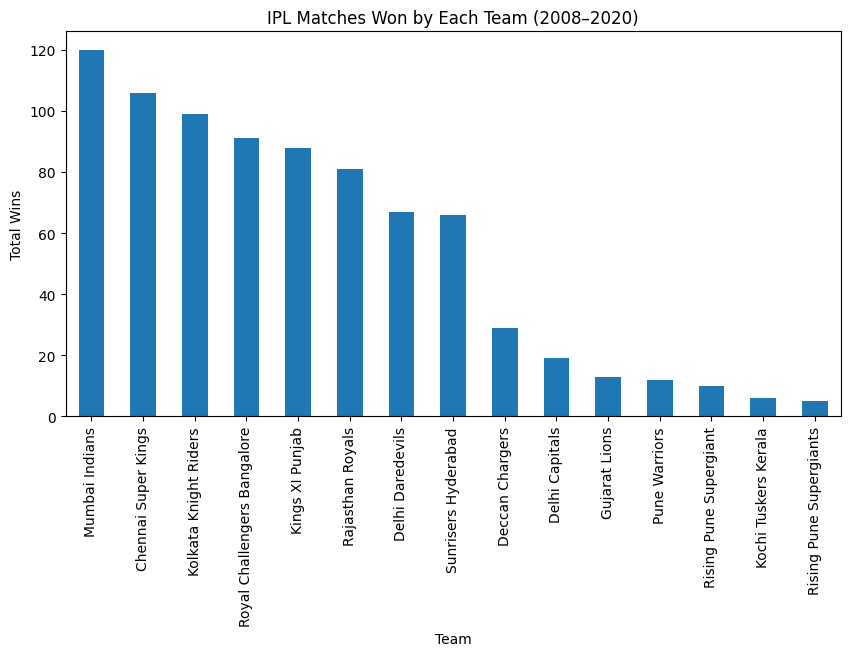

In [79]:
most_matches_win.plot(
    x = 'Team',
    y = 'Total Wins',
    kind = 'bar',
    legend = False,
    figsize = (10,5)
)
plt.title('IPL Matches Won by Each Team (2008–2020)')
plt.xlabel('Team')
plt.ylabel('Total Wins')
plt.xticks(rotation=90)

plt.savefig('IPL Matches Won by Each Team (2008–2020).png')
plt.show()

# 3. Which teams have the highest winning percentage?

In [50]:
matches_won = match['winner'].value_counts()
matches_played = (pd.concat([match['team1'], match['team2']]).value_counts())

winning_percentage = (matches_won / matches_played * 100).round(2)

In [51]:
team_winning_percentage = pd.DataFrame({
    'Match Won': matches_won,
    'Matches Played': matches_played,
    'Winning Percentage': winning_percentage 
})

team_winning_percentage = (
    team_winning_percentage
    .fillna(0)
    .sort_values(
        by = 'Winning Percentage',
        ascending = False
    )
    .reset_index()
)    

team_winning_percentage.columns = [
    'Teams',
    'Matches Won',
    'Matches Playes',
    'Winning Percentage'
]
team_winning_percentage

,Teams,Matches Won,Matches Playes,Winning Percentage
0,Rising Pune Supergiant,10,16,62.50
1,Chennai Super Kings,106,178,59.55
2,Mumbai Indians,120,203,59.11
3,Delhi Capitals,19,33,57.58
4,Sunrisers Hyderabad,66,124,53.23
5,Kolkata Knight Riders,99,192,51.56
6,Rajasthan Royals,81,161,50.31
7,Royal Challengers Bangalore,91,195,46.67
8,Kings XI Punjab,88,190,46.32
9,Gujarat Lions,13,30,43.33


In [52]:
print(f'Heighest Winning Percenatge: {team_winning_percentage['Teams'][0]} {team_winning_percentage['Winning Percentage'][0]}%')

Heighest Winning Percenatge: Rising Pune Supergiant 62.5%


# 4. Which venues have hosted the most IPL matches?

In [53]:
host_most_matches = (
    match['venue']
    .value_counts()
    .reset_index(name = 'Total Matches')
)
host_most_matches.head(1).style.hide(axis="index")

venue,Total Matches
Eden Gardens,77


# 5. Which players have won the most Player of the Match awards?

In [54]:
player_of_the_match = (
    match['player_of_match']
    .value_counts()
    .reset_index(name = 'Player of the Match Awards')
    .rename(columns={'player_of_match':'Player'})
)
player_of_the_match.head(1).style.hide(axis='index')

Player,Player of the Match Awards
AB de Villiers,23


# 6. Does winning the toss increase the chances of winning the match?

In [55]:
toss_match_result = (
    (match['toss_winner'] == match['winner'])
    .value_counts()
    .reset_index()
    )
toss_match_result.columns = ['Toss Winner Won Match', 'Total Matches']
toss_match_result['Win Percentage'] = (
    toss_match_result['Total Matches']/toss_match_result['Total Matches'].sum() * 100
).round(2)

toss_match_result.style.hide(axis='index')

Toss Winner Won Match,Total Matches,Win Percentage
True,418,51.230000
False,398,48.770000


# 7. What are the most common toss decisions?

In [56]:
common_toss_decision = (
    match['toss_decision']
    .value_counts()
    .reset_index()
)
common_toss_decision.columns = ['Toss Decision', 'Total']
common_toss_decision.style.hide(axis = 'index')

Toss Decision,Total
field,496
bat,320


# 8. Which teams perform best after choosing to bat or field?

In [57]:
match['Toss_Winner_Won'] = (
    match['toss_winner'] == match['winner']
)

team_decision_performance = (
    match
    .groupby(['toss_winner', 'toss_decision'])
    .agg(
        Matches=('id', 'count'),
        Matches_Won=('Toss_Winner_Won', 'sum')
    )
    .reset_index()
)

team_decision_performance['Win Percentage'] = (
    team_decision_performance['Matches_Won']
    / team_decision_performance['Matches']
    * 100
).round(2)

team_decision_performance = (
    team_decision_performance
    .sort_values(
        'Win Percentage',
        ascending=False
    )
)

best_bat = (
    team_decision_performance[
        team_decision_performance['toss_decision'] == 'bat'
    ]
    .head(1)
)

best_field = (
    team_decision_performance[
        team_decision_performance['toss_decision'] == 'field'
    ]
    .head(1)
)

In [58]:
best_field

,toss_winner,toss_decision,Matches,Matches_Won,Win Percentage
22,Rising Pune Supergiant,field,6,5,83.33


In [59]:
best_bat

,toss_winner,toss_decision,Matches,Matches_Won,Win Percentage
0,Chennai Super Kings,bat,51,31,60.78


# 9. Most Player of the Match Awards

In [60]:
Player_of_the_Match_Awards = (
    match['player_of_match']
    .value_counts()
    .reset_index()
)    
Player_of_the_Match_Awards.columns = ['Player Of The Match', 'Total'] 
Player_of_the_Match_Awards.head(1).style.hide(axis = 'index')

Player Of The Match,Total
AB de Villiers,23


# 10. Most Popular Venues

In [61]:
most_popular_venues = (
    match['venue']
    .value_counts()
    .reset_index()
)
most_popular_venues.columns = ['Venue', 'Total']
most_popular_venues.head(1).style.hide(axis = 'index')

Venue,Total
Eden Gardens,77


# Ball-by-Ball Analysis

# 11. Who are the top run scorers in IPL from 2008–2020?

In [62]:
top_scorer = (
    ball_by_ball
    .groupby('batsman')
    .agg(
        Total_Runs=('batsman_runs', 'sum')
    )
    .sort_values(
        by='Total_Runs',
        ascending=False
    )
    .reset_index()
)

top_scorer.head(3)

,batsman,Total_Runs
0,V Kohli,5878
1,SK Raina,5368
2,DA Warner,5254


# 12. Which players have hit the most sixes?

In [63]:
player_most_sixes = (
    ball_by_ball[ball_by_ball['batsman_runs'] == 6]
    .groupby('batsman')
    .size()    
    .reset_index(name = 'Sixes')    
    .sort_values(
        by = 'Sixes',
        ascending = False
    )
    .reset_index(drop=True)
)
player_most_sixes.index = player_most_sixes.index + 1
player_most_sixes.head(5)

,batsman,Sixes
1,CH Gayle,349
2,AB de Villiers,235
3,MS Dhoni,216
4,RG Sharma,214
5,V Kohli,202


# 13. Which bowlers have taken the most wickets from 2008–2020?

In [64]:
most_wicket = (
    ball_by_ball[ball_by_ball['is_wicket'] == 1]
    .groupby('bowler')    
    .size()
    .reset_index(name = 'Wickets')
    .sort_values(
        by = 'Wickets',
        ascending = False
    )
    .reset_index(drop = True)
)
most_wicket.index = most_wicket.index + 1
most_wicket.head()

,bowler,Wickets
1,SL Malinga,188
2,DJ Bravo,175
3,A Mishra,169
4,PP Chawla,164
5,Harbhajan Singh,161


# 14. Which teams have scored the most runs?

In [65]:
team_most_runs = (
    ball_by_ball
    .groupby('batting_team')
    .agg(
        Total_Runs=('total_runs', 'sum')
    )
    .sort_values(
        by='Total_Runs',
        ascending=False
    )
    .reset_index()
)

team_most_runs.index = team_most_runs.index + 1

team_most_runs.head(3)

,batting_team,Total_Runs
1,Mumbai Indians,32286
2,Royal Challengers Bangalore,30214
3,Kings XI Punjab,30017


# 15. What are the highest-scoring matches?

In [66]:
most_runs_single_match = (
    ball_by_ball
    .groupby(['id', 'batting_team'])
    .agg(
        Total_Runs=('total_runs', 'sum')
    )
    .reset_index()
    .sort_values(
        by='Total_Runs',
        ascending=False
    )
)

most_runs_single_match.head(3).style.hide(axis = 'index')

id,batting_team,Total_Runs
598027,Royal Challengers Bangalore,263
980987,Royal Challengers Bangalore,248
419137,Chennai Super Kings,246


# 16. Which teams have the highest average runs per match?

In [67]:
matches_played_per_team = (
    pd.concat([match['team1'], match['team2']])
    .value_counts()
)

highest_avg_runs_per_match = (
    ball_by_ball
    .groupby('batting_team')
    .agg(
        Total_Runs=('total_runs', 'sum')
    )
    .reset_index()
)

highest_avg_runs_per_match['Matches_Played'] = (
    highest_avg_runs_per_match['batting_team']
    .map(matches_played_per_team)
)

highest_avg_runs_per_match['Avg_Runs_Per_Match'] = (
    round(highest_avg_runs_per_match['Total_Runs']
    / highest_avg_runs_per_match['Matches_Played'], 2)
)

highest_avg_runs_per_match = (
    highest_avg_runs_per_match
    .sort_values(
        by='Avg_Runs_Per_Match',
        ascending=False
    )
)
highest_avg_runs_per_match.head(1)

,batting_team,Total_Runs,Matches_Played,Avg_Runs_Per_Match
4,Gujarat Lions,4856,30,161.87


# Visualizations

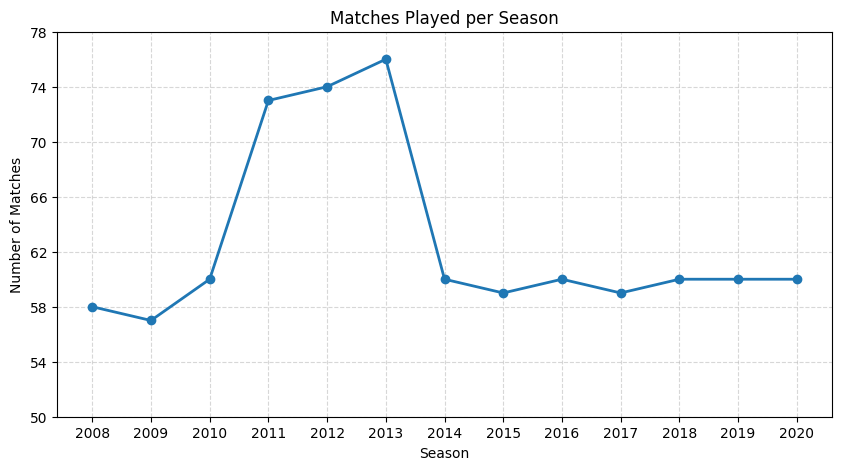

In [68]:
matches_played_per_season = match['Season'].value_counts().sort_index()
plt.figure(figsize=(10, 5))
plt.plot(
    matches_played_per_season.index, 
    matches_played_per_season.values,
    marker='o',
    linewidth=2
)
plt.title('Matches Played per Season')
plt.xlabel('Season')
plt.ylabel('Number of Matches')
plt.xticks(matches_played_per_season.index)
plt.yticks(range(50, 80, 4))
plt.grid(True, linestyle='--', alpha=0.5)

plt.savefig('Matches playes per Season.png')
plt.show()

# 1. Matches played per season

# 2. Total wins by team

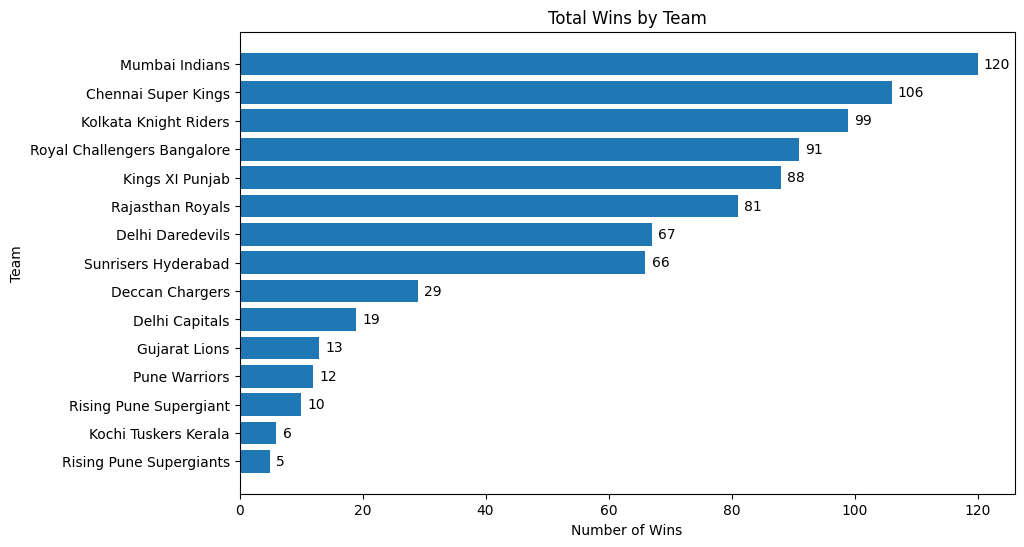

In [70]:
matches_winner = match['winner'].value_counts()
plt.figure(figsize=(10, 6))
plt.barh(
    matches_winner.index[::-1],
    matches_winner.values[::-1]
)
plt.title('Total Wins by Team')
plt.xlabel('Number of Wins')
plt.ylabel('Team')

for i, value in enumerate(matches_winner.values[::-1]):
    plt.text(value + 1, i, str(value), va='center')

plt.savefig('Total Wins by Team.png')
plt.show()

# 3. Winning percentage by team

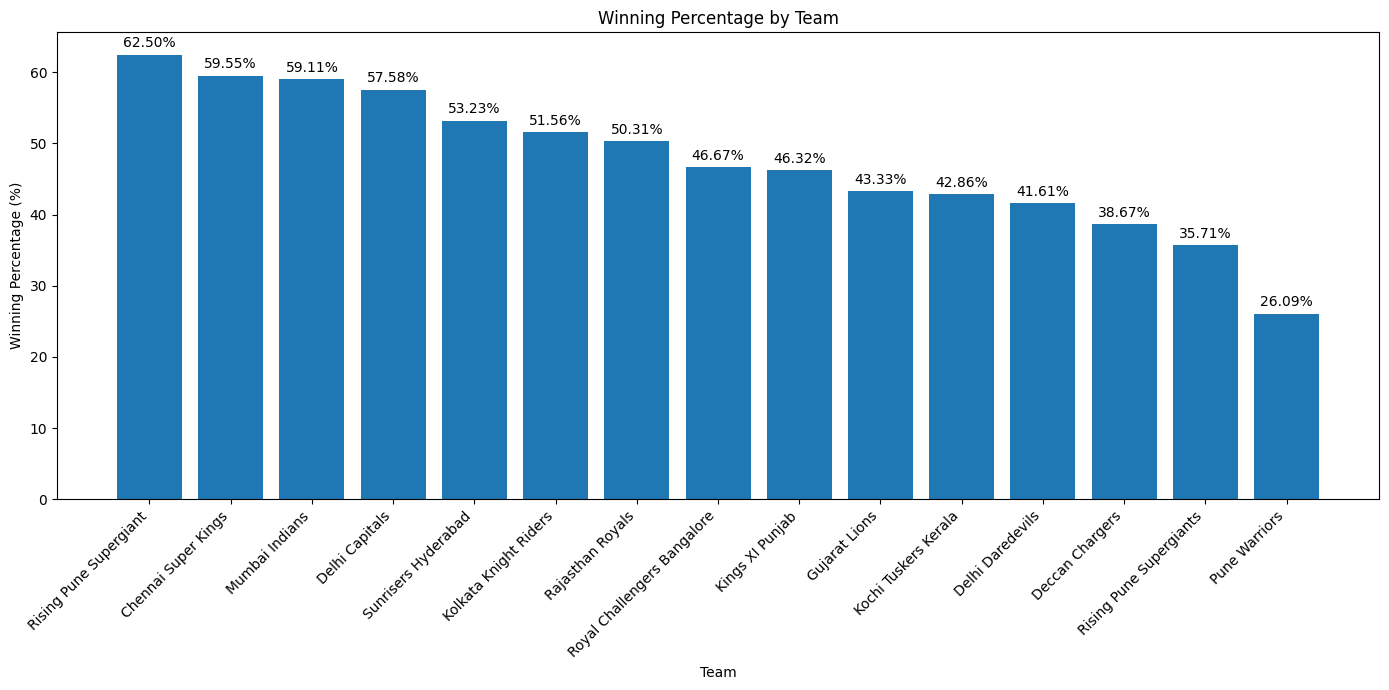

In [71]:
plt.figure(figsize=(14, 7))

bars = plt.bar(
    team_winning_percentage['Teams'],
    team_winning_percentage['Winning Percentage']
)

plt.title('Winning Percentage by Team')
plt.xlabel('Team')
plt.ylabel('Winning Percentage (%)')

plt.xticks(rotation=45, ha='right')

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        f'{height:.2f}%',
        ha='center'
    )

plt.tight_layout()
plt.savefig('Winning Percentage by Team.png')
plt.show()

# 4. Toss winner vs match winner

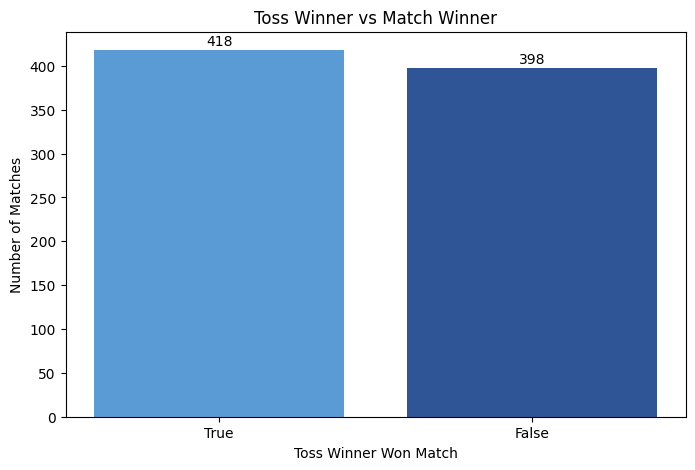

In [72]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    toss_match_result['Toss Winner Won Match'].astype(str),
    toss_match_result['Total Matches'],
    color=['#5B9BD5', '#2F5597']
)

plt.title('Toss Winner vs Match Winner')
plt.xlabel('Toss Winner Won Match')
plt.ylabel('Number of Matches')

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 5,
        f'{height:.0f}',
        ha='center'
    )
plt.savefig('Toss Winner vs Match Winner.png')
plt.show()

# 5. Top Player of the Match awards (Top 5)

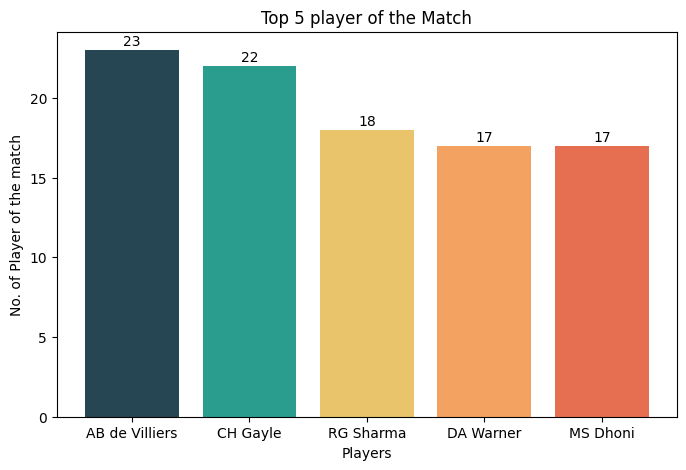

In [73]:
plt.figure(figsize=(8, 5))
colors = [
    '#264653',
    '#2A9D8F',
    '#E9C46A',
    '#F4A261',
    '#E76F51'
]
bars = plt.bar(
    Player_of_the_Match_Awards.head(5)['Player Of The Match'],
    Player_of_the_Match_Awards.head(5)['Total'],
    color = colors
)
plt.title('Top 5 player of the Match')
plt.xlabel('Players')
plt.ylabel('No. of Player of the match')

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.3,
        f'{height:.0f}',
        ha='center'
    )
plt.savefig('Top 5 player of the Match.png')
plt.show()

# 6. Most-used venues

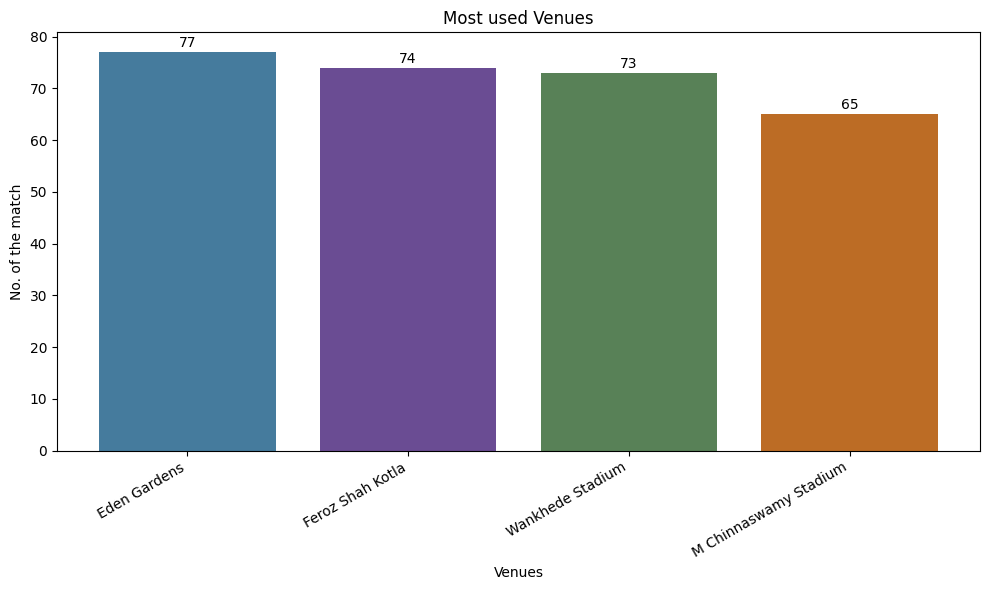

In [74]:
plt.figure(figsize =(10, 6))
bars = plt.bar(
    host_most_matches.head(4)['venue'],
    host_most_matches.head(4)['Total Matches'],
    color = ['#457B9D','#6A4C93','#588157','#BC6C25','#8D99AE']
)
plt.title('Most used Venues')
plt.xlabel('Venues')
plt.ylabel('No. of the match')
plt.xticks(rotation=30, ha='right')

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        f'{height:.0f}',
        ha='center'
    )
plt.tight_layout()
plt.savefig('Most used Venues.png')
plt.show()    

# 7. Top 10 run scorers in IPL from (2008-2020)

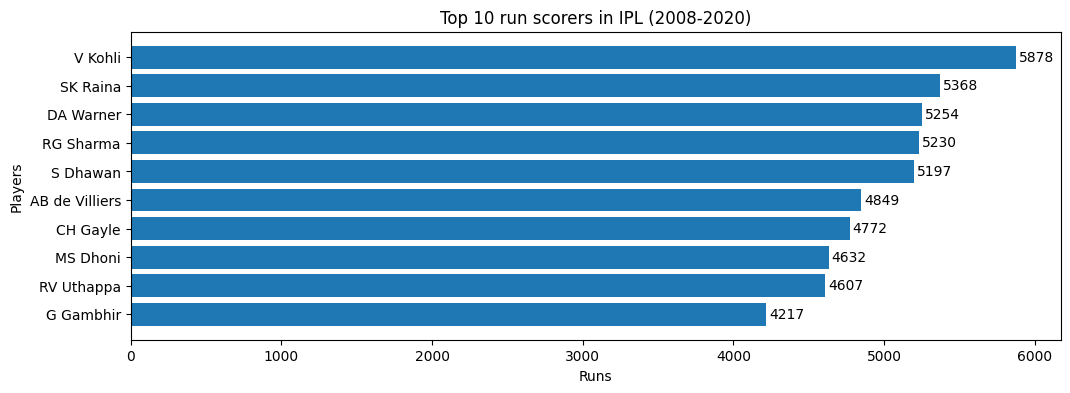

In [75]:
plt.figure(figsize = (12, 4))
top_10 = top_scorer.head(10)
plt.barh(
    top_10['batsman'][::-1],
    top_10['Total_Runs'][::-1]
)

plt.title('Top 10 run scorers in IPL (2008-2020)')
plt.xlabel('Runs')
plt.ylabel('Players')
for i, value in enumerate(top_10['Total_Runs'][::-1]):
    plt.text(
        value + 20,
        i,
        str(value),
        va='center'
    )
plt.savefig('Top 10 run scorers in IPL (2008-2020).png')    
plt.show()

# 8. Top 10 wicket takers 

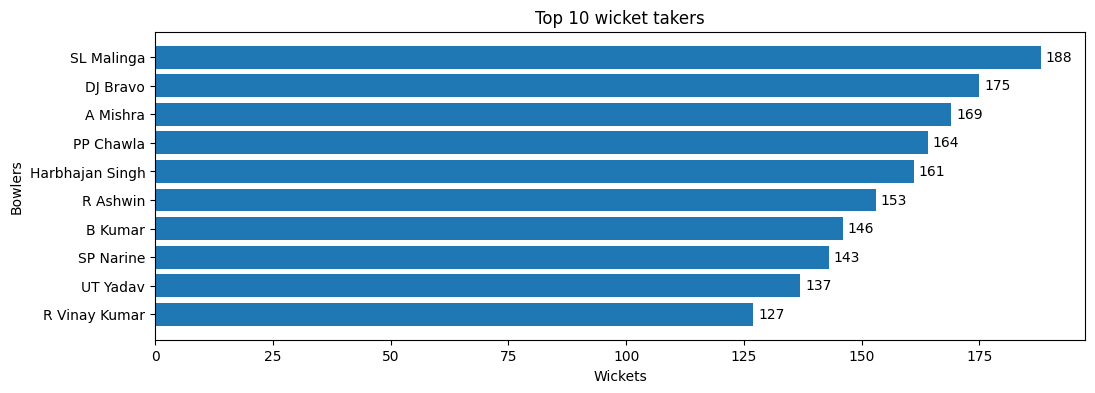

In [76]:
plt.figure(figsize=(12, 4))
plt.barh(
    most_wicket.head(10)['bowler'][::-1],
    most_wicket.head(10)['Wickets'][::-1]
)
plt.title('Top 10 wicket takers')
plt.xlabel('Wickets')
plt.ylabel('Bowlers')
for i, value in enumerate(most_wicket.head(10)['Wickets'][::-1]):
    plt.text(
        value + 1,
        i,
        str(value),
        va='center'
    )
plt.savefig('Top 10 wicket takers.png') 
plt.show()

# 9. Most sixes

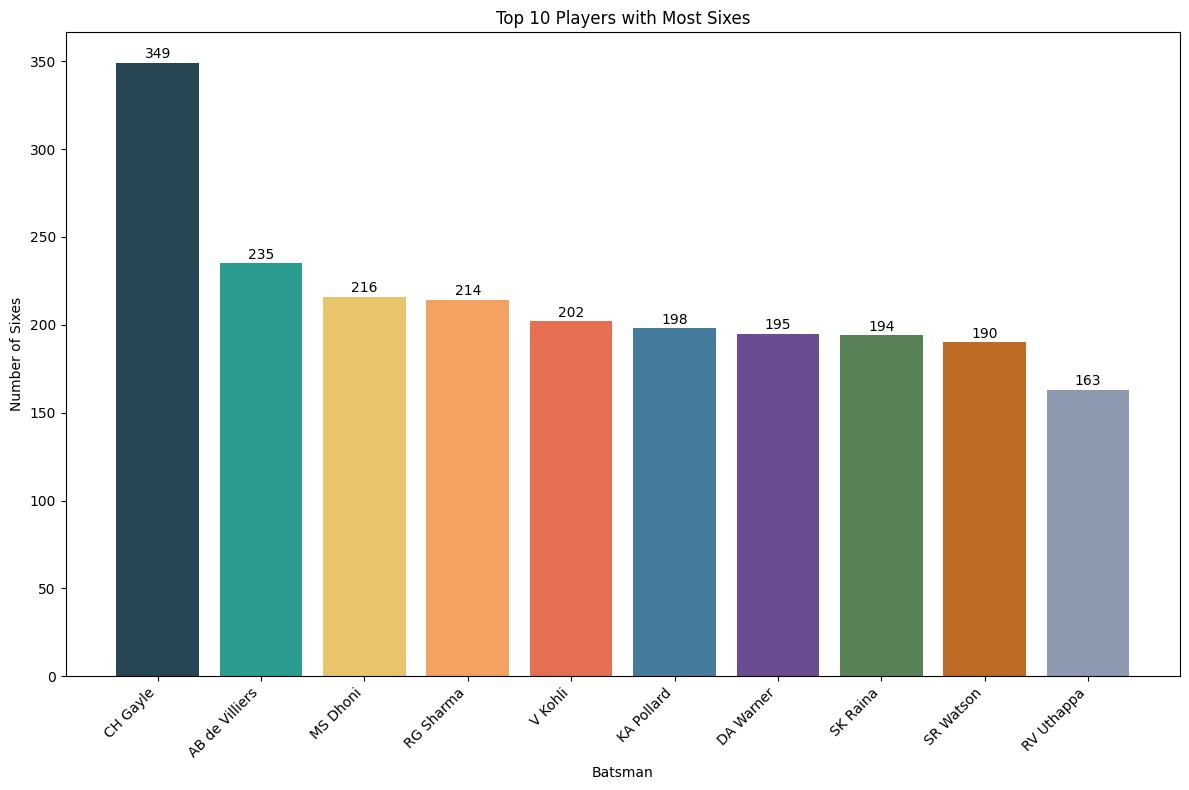

In [77]:
top_players_most_sixes = player_most_sixes.head(10)
colors = [
    '#264653',
    '#2A9D8F',
    '#E9C46A',
    '#F4A261',
    '#E76F51',
    '#457B9D',
    '#6A4C93',
    '#588157',
    '#BC6C25',
    '#8D99AE'
]
plt.figure(figsize=(12, 8))

bars = plt.bar(
    top_players_most_sixes['batsman'],
    top_players_most_sixes['Sixes'],
    color = colors
)

plt.title('Top 10 Players with Most Sixes')
plt.xlabel('Batsman')
plt.ylabel('Number of Sixes')

plt.xticks(rotation=45, ha='right')

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        str(int(height)),
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.savefig('Top 10 Players with Most Sixes.png') 
plt.show()

# 10. Average runs per match by team

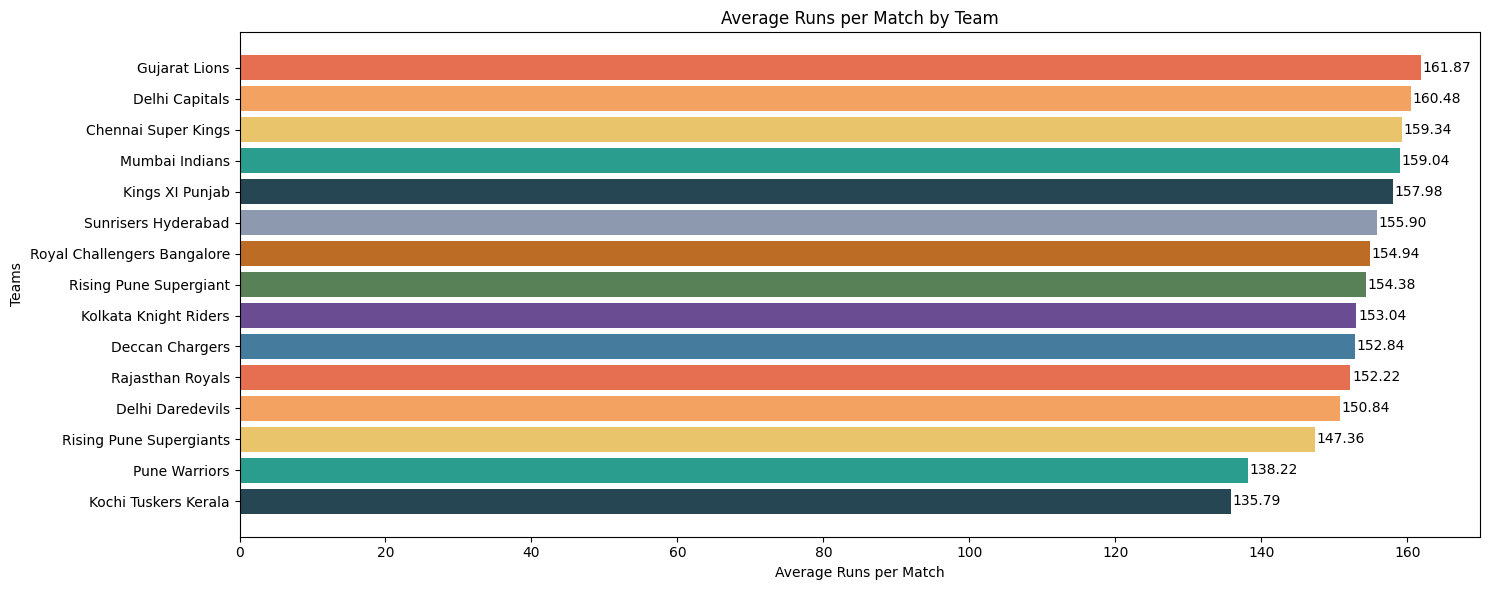

In [78]:
plt.figure(figsize=(15, 6))

bars = plt.barh(
    highest_avg_runs_per_match['batting_team'][::-1],
    highest_avg_runs_per_match['Avg_Runs_Per_Match'][::-1],
    color = colors
)

plt.title('Average Runs per Match by Team')
plt.xlabel('Average Runs per Match')
plt.ylabel('Teams')

for i, value in enumerate(highest_avg_runs_per_match['Avg_Runs_Per_Match'][::-1]):
    plt.text(
        value + 0.2,
        i,
        f'{value:.2f}',
        va='center'
    )

plt.tight_layout()
plt.savefig('Average Runs per Match by Team.png') 
plt.show()

# Key Insights

**1. <u> Seasonal match variation</u>**

The IPL recorded its **highest number of matches in 2013, with 76 matches**, while **2009 had the lowest with 57 matches**. From 2016 onward, the tournament mostly remained around **59–60 matches per season**.
<br>Insight: Match volume changed considerably during the early IPL seasons before becoming relatively stable in later seasons.

<br>**2. <u>Most Wins </u>**

**Mumbai Indians recorded 120 wins**, the highest in the dataset, followed by **Chennai Super Kings with 106 wins** and **Kolkata Knight Riders with 99 wins**.
<br>Insight: These teams accounted for a substantial number of match victories during the 2008–2020 period.

<br>**3. <u>Winning Percentage</u>**

**Rising Pune Supergiant recorded the highest winning percentage at 62.50%**, but this came from only 16 matches.
Among teams with a much larger number of matches, **Chennai Super Kings recorded 59.55% (106 wins from 178 matches) and Mumbai Indians recorded 59.11% (120 wins from 203 matches)**.
<br>Insight: Total wins and winning percentage measure different aspects of performance, and **sample size should be considered when interpreting winning percentage**.

<br>**4.<u> Toss impact</u>**

The toss winner won the match **418 out of 816 matches (51.23%)**, while losing **398 matches (48.77%)**.
Insight: The difference was only **2.46 percentage points**, suggesting that winning the toss alone did not strongly determine the match outcome in this dataset.

<br>**5.<u> Toss preference </u>**

Among the combinations in your analysis, **Rising Pune Supergiant won 5 of 6 matches (83.33%)** after choosing to field, while **Chennai Super Kings won 31 of 51 matches (60.78%)** after choosing to bat.
<br>Insight: Success after a toss decision varied across teams, but the **small sample size for some teams means these percentages should be interpreted cautiously**.

<br>**6.<u>Top run scorer</u>**

**V Kohli scored 5,878 runs**, followed by **SK Raina with 5,368** and **DA Warner with 5,254**.
<br>Kohli's lead over Raina was **510 runs**.
<br>Insight: The top of the run-scoring table was dominated by a small group of highly productive batsmen.

<br>**7.<u>Top wicket taker</u>**

**SL Malinga took 188 wickets**, followed by **DJ Bravo with 175** and **A Mishra with 169**.
<br>Malinga's lead over Bravo was **13 wickets**.
<br>Insight: The leading wicket-takers maintained a relatively close gap at the top compared with some other performance categories.

<br>**8.<u>Most sixes</u>**

**CH Gayle hit 349 sixes**, followed by **AB de Villiers with 235**, **MS Dhoni with 216**, and **RG Sharma with 214**.
<br>Gayle hit **114 more sixes than AB de Villiers**, giving him a substantial lead over the second-ranked player.
<br>Insight: The six-hitting distribution shows a particularly strong concentration at the top of the leaderboard.

# Conclusion

This project analyzed **IPL match and ball-by-ball data from 2008 to 2020** to understand team performance, player performance, match outcomes, toss decisions, scoring patterns, and venue distribution.

The analysis revealed several important patterns. **Mumbai Indians recorded the highest number of wins with 120**, while **V Kohli led the run-scoring charts with 5,878 runs** and **SL Malinga led the wicket-taking charts with 188 wickets**. **CH Gayle recorded the highest number of sixes with 349**, demonstrating the impact of power-hitting in the tournament.

The toss analysis showed that the toss winner won **51.23% of the 816 matches**, indicating that winning the toss provided only a **slight advantage** rather than strongly determining the match result. Teams also showed a clear preference for **fielding first, chosen in 60.78% of tosses**.

Overall, the project demonstrates how **Python, Pandas, SQL, data cleaning, exploratory data analysis, and data visualization** can be used to transform raw sports data into meaningful insights. It also highlights the importance of considering **multiple metrics, sample size, and data quality** when interpreting analytical results.

**This project provided practical experience in analyzing real-world data and communicating data-driven findings through clear visualizations and insights.**